# High-level analysis

**Doses, effect direction and magnitude, stated durations, and categorized adverse events,
re-extracted from raw Reddit text for a cohort that was already known to report these drugs.**

This is the descriptive picture over the whole extraction: what people reported, how much of
it there is, and what each number's denominator is. It takes the cohort, the extraction
contract and the reliability of the extractor as established in notebook 1, and leaves
symptom-specific heterogeneity, contrasts and robustness checks to notebook 3.

Every figure below is a **share of extractable reports** and carries its denominator. None of
them is an incidence, a response rate, or a dose-response relationship.

**This is one of three notebooks over the same pinned extraction run.**

| | notebook | what it answers |
|---|---|---|
| 1 | `psychedelics_v2_01_methods` | who is in the cohort, what the extractor did, and how well it did it |
| 2 | `psychedelics_v2_02_overview` | the headline descriptive picture: direction, magnitude, duration, adverse events, doses |
| 3 | `psychedelics_v2_03_deep_dive` | symptom-specific heterogeneity, contrasts, robustness, and what to validate first |

They share one loader and one setup cell, and every one of them is a description
of extractable Reddit reporting patterns rather than a measurement of any drug.

In [1]:
import html
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

V2_DIR = next(c for p in (Path.cwd(), *Path.cwd().parents)
              for c in (p, p / "studies/psychedelics/v2")
              if (c / "psychedelics_v2.py").is_file())
sys.path.insert(0, str(V2_DIR))
import psychedelics_v2 as P
from psychedelics_v2 import (BASE_SEED, DRUG_COLORS, MIN_PATIENTS, MIN_ROWS, N_BOOT,
                             clustered_difference, clustered_rate, cohens_h,
                             direction_profile, interval_note, meets_gate, seed_for)

# The run is pinned by full id, never resolved implicitly: a database holding
# more than one run would otherwise be settled by whichever row came back first,
# so `load_frames` raises if this id is absent or not unique.
RUN_ID = "710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05"
DB_PATH = P.db_path()
f = P.load_frames(DB_PATH, run_id=RUN_ID)

# `included` already IS the self-reported actual-use population; `actual_use`
# asserts that identity rather than re-filtering for it.
u = P.actual_use(f)
actual_claims, actual_claim_ids = u.claims, u.claim_ids
effects, adverse, doses = u.effects, u.adverse, u.doses
actual_pairs, cohort_pairs = u.pairs, u.cohort_pairs
inc = actual_claims
pde = P.patient_drug_effects(f)

DRUGS, DIRECTIONS = list(P.DRUGS), list(P.DIRECTIONS)
SYMPTOMS = list(P.SYMPTOM_ORDER)
ROUTE_DRUG = "ketamine"   # stated route is interpreted for ketamine only
duration_labels = P.DURATION_LABELS
provenance = P.provenance_table(DB_PATH, f)

P.apply_style(plt)
sns.set_style("whitegrid")
print(f"included claims = self-reported actual use: {len(actual_claims):,} claims, "
      f"{len(actual_pairs):,} reporter-drug pairs")

included claims = self-reported actual use: 2,921 claims, 953 reporter-drug pairs


---
# 1. Effect direction

## 1.1 Reporter-level: what share of people reported each direction

One row per (reporter, drug) pair with at least one effect record. The four categories
**overlap by construction** — a person who reports that psilocybin helped their mood and did
nothing for their fatigue appears in both `helped` and `no_effect`. They are not a partition
and do not sum to 100%.

Read these as *"of the people whose text yielded an extractable effect for this drug, this
share said it helped at least once"*. Not: how often it works.

The three drugs' any-helped shares sit close together and their intervals overlap. **That is
not evidence that they are equivalent.** No equivalence margin was prespecified and no
equivalence test was performed, so an overlap here describes the precision of these estimates
and nothing more; a clinically meaningful difference could sit comfortably inside these
intervals. The estimates and their intervals are given above to be read descriptively.

The visible difference is elsewhere: ketamine pairs report `no_effect` at roughly 29%, against
17% for psilocybin. Ketamine's dose records state IV/IM routes far more often than the other
arms (§5.2), and injected use plausibly travels with a different reporting context; setting is
unmeasured in this run (notebook 3, §11), so that is a candidate explanation, not a measured one.


,drug,direction,k,n,rate,ci_lo,ci_hi
0,psilocybin,helped,304,341,0.891,0.854,0.920
1,psilocybin,no_effect,59,341,0.173,0.137,0.217
2,psilocybin,worsened,32,341,0.094,0.067,0.129
3,psilocybin,mixed,19,341,0.056,0.036,0.085
4,ketamine,helped,294,352,0.835,0.793,0.870
5,ketamine,no_effect,103,352,0.293,0.248,0.342
6,ketamine,worsened,30,352,0.085,0.060,0.119
7,ketamine,mixed,8,352,0.023,0.012,0.044
8,lsd,helped,46,54,0.852,0.734,0.923
9,lsd,no_effect,12,54,0.222,0.132,0.349


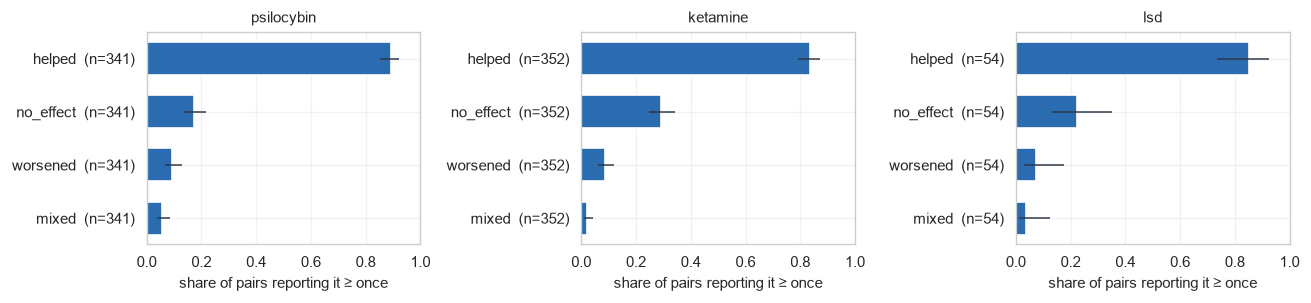

In [2]:
dm = P.direction_mix(f, level="patient")
display(dm.round(3))

fig, axes = plt.subplots(1, 3, figsize=(11, 2.6), sharex=True)
for ax, d in zip(axes, P.DRUGS):
    sub = dm[dm.drug == d]
    P.ci_bars(ax, sub.direction.tolist(), sub.rate.tolist(), sub.ci_lo.tolist(),
              sub.ci_hi.tolist(), sub.n.tolist(),
              color=P.COLORS["accent"], title=d)
    ax.set_xlabel("share of pairs reporting it ≥ once")
plt.tight_layout(); plt.show()

## 1.2 The same people, as mutually exclusive profiles

The overlap above is easier to read as a partition. Roughly two thirds of pairs report
nothing but improvement; about a fifth report a mix of directions for the same drug, which
is exactly the pattern a per-claim rate would flatten away.

profile,helped only,mixed / conflicting,no effect only,worsened only
drug,,,,
psilocybin,246,69,17,9
ketamine,225,74,40,13
lsd,38,10,6,0


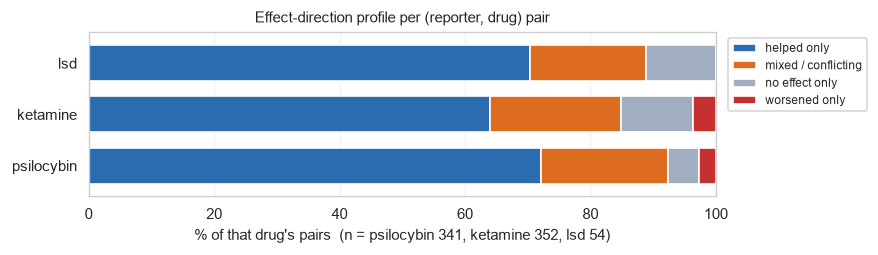

In [3]:
prof = (pde.groupby(["drug", "profile"]).size().unstack(fill_value=0)
        .reindex(index=list(P.DRUGS),
                 columns=["helped only", "mixed / conflicting", "no effect only",
                          "worsened only"], fill_value=0))
display(prof)

pct = 100 * prof.div(prof.sum(axis=1), axis=0)
ax = pct.plot(kind="barh", stacked=True, figsize=(7.4, 2.2), width=0.7,
              color=["#2b6cb0", "#dd6b20", "#a0aec0", "#c53030"])
ax.set_xlabel("% of that drug's pairs  (n = "
              + ", ".join(f"{d} {int(prof.loc[d].sum())}" for d in P.DRUGS) + ")")
ax.set_ylabel("")
ax.set_title("Effect-direction profile per (reporter, drug) pair", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 1.3 Event level, for contrast — and why it is not the headline

The same data counted per effect record. The point estimate barely moves, which is not
reassurance: the two numbers answer different questions, and the event-level interval is
**wrong**, not merely different. It assumes 2,890 independent observations when the top 1%
of pairs supply nearly a fifth of them.

It is printed only so the gap between the two framings is visible.

In [4]:
ev = P.direction_mix(f, level="event")
display(ev.assign(total=ev.sum(axis=1)))

e = f.effects
k, n = int((e.direction == "helped").sum()), len(e)
est, lo, hi = P.wilson(k, n)
pl = pde
kp, np_ = int(pl.any_helped.sum()), len(pl)
estp, lop, hip = P.wilson(kp, np_)
print(f"event level   'helped' {est:.3f}  [{lo:.3f}, {hi:.3f}]  n={n:,} effect records"
      f"   ← CLUSTERED, interval is too narrow")
print(f"pair level  'any helped' {estp:.3f}  [{lop:.3f}, {hip:.3f}]  n={np_:,} pairs")
print(f"interval width: event {hi - lo:.3f}  vs  pair {hip - lop:.3f}")

direction,helped,no_effect,worsened,mixed,total
drug,,,,,
psilocybin,1135,93,61,19,1308
ketamine,1215,158,65,10,1448
lsd,110,14,8,2,134


event level   'helped' 0.851  [0.838, 0.864]  n=2,890 effect records   ← CLUSTERED, interval is too narrow
pair level  'any helped' 0.862  [0.836, 0.885]  n=747 pairs
interval width: event 0.026  vs  pair 0.049


## 1.4 What the effects were reported *about*

The model records a free-text target for about two thirds of effect records. Those strings
are never displayed; they are mapped into coarse symptom classes, and anything that does not
match one of them stays in `other`.

v1's single `energy_pem` class is not used here. One pattern matched `pem`, `fatigue`, `energy`,
`tired`, `exhaust` and `crash` together and the result was reported as post-exertional malaise,
which nonspecific tiredness does not establish. The four constructs are separated below:
`pem_explicit` needs the target to state post-exertional worsening, `exertion_intolerance` covers
exertion and exercise language without it, and `fatigue_general` and `low_energy` carry the
nonspecific remainder. Classification is also multilabel — a target naming brain fog *and*
fatigue belongs to both classes — and the table below counts each record once, under the most
specific class it matches.

The mood/cognitive class dominates, which matches v1's finding that the people who write
about these drugs in this community are carrying a heavy psychiatric load. Explicit PEM — the
class that would matter most for a specifically post-viral claim — is the smallest named class
by a wide margin, which is why notebook 3 reports no PEM result.

symptom_class,pem_explicit,exertion_intolerance,fatigue_general,low_energy,mood_cognitive,pain,other,unspecified
drug,,,,,,,,
psilocybin,14,2,30,22,343,35,403,459
ketamine,26,2,53,21,334,156,383,473
lsd,1,1,12,5,26,6,47,36


,records (multilabel),reporters (multilabel)
symptom class,,
pem_explicit,41,19
exertion_intolerance,9,9
pain,197,107
mood_cognitive,730,303
fatigue_general,127,82
low_energy,67,49
other,833,292
unspecified,968,327


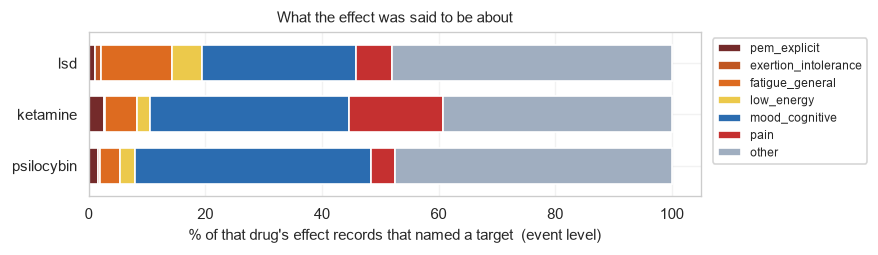

In [5]:
SYMPTOM_ORDER = ["pem_explicit", "exertion_intolerance", "fatigue_general", "low_energy",
                 "mood_cognitive", "pain", "other", "unspecified"]
assert set(SYMPTOM_ORDER) == set(P.SYMPTOM_CLASSES)
sym = (e.groupby(["drug", "symptom_class"]).size().unstack(fill_value=0)
       .reindex(index=list(P.DRUGS), columns=SYMPTOM_ORDER, fill_value=0))
display(sym)

# Multilabel membership, so a target naming two symptoms is counted under both.
display(P.symptom_composition(e)[["records (multilabel)", "reporters (multilabel)"]])

named = sym.drop(columns=["unspecified"])
pct = 100 * named.div(named.sum(axis=1), axis=0)
ax = pct.plot(kind="barh", stacked=True, figsize=(7.4, 2.2), width=0.7,
              color=["#742a2a", "#c05621", "#dd6b20", "#ecc94b",
                     "#2b6cb0", "#c53030", "#a0aec0"])
ax.set_xlabel("% of that drug's effect records that named a target  (event level)")
ax.set_ylabel("")
ax.set_title("What the effect was said to be about", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

---
# 2. Magnitude — and the two very different things it can mean

`magnitude_0_10` carries a `magnitude_basis` saying where the number came from:

* **`author_numeric`** — the author supplied a rating. This is data.
* **`model_rubric`** — the model graded the language against a rubric in the prompt. This is
  the model's reading of adjectives, and it is not evidence of the same kind.

**These must never be pooled.** There are 14 author-supplied ratings in the entire corpus
against 988 model-graded ones, so any pooled "mean magnitude" would be a statistic about the
model's rubric wearing a reporter's clothes.

In [6]:
mag = e[e.magnitude.notna()]
display(pd.crosstab(mag.magnitude_basis, mag.drug, margins=True, margins_name="total"))
print(f"effect records with any magnitude: {len(mag):,} of {len(e):,} "
      f"({len(mag) / len(e):.0%})")
print(f"author_numeric: {int((mag.magnitude_basis == 'author_numeric').sum())} records, "
      f"{mag[mag.magnitude_basis == 'author_numeric'].patient.nunique()} reporter accounts")

drug,ketamine,lsd,psilocybin,total
magnitude_basis,,,,
author_numeric,4,0,10,14
model_rubric,381,48,559,988
total,385,48,569,1002


effect records with any magnitude: 1,002 of 2,890 (35%)
author_numeric: 14 records, 13 reporter accounts


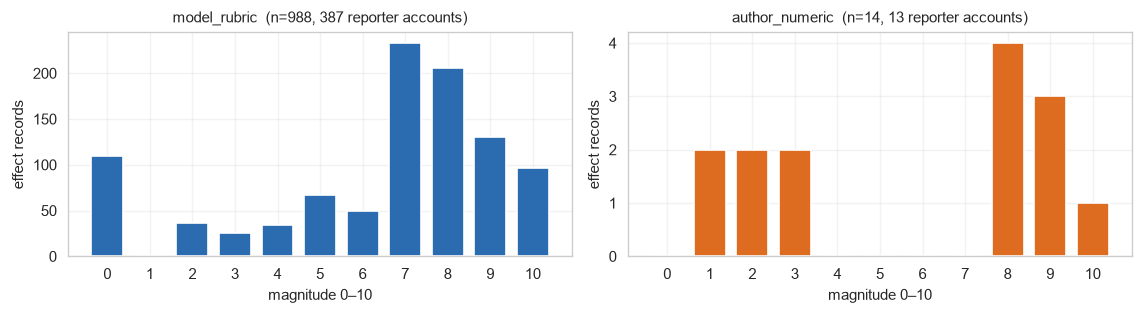

The model_rubric distribution is bimodal at 0 and 7–10, i.e. the rubric mostly
distinguishes 'nothing happened' from 'a lot happened' and rarely lands in between.
That is a property of the grader, not a measured distribution of effect sizes.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 2.7), sharey=False)
for ax, basis, color in zip(axes, ["model_rubric", "author_numeric"],
                            [P.COLORS["accent"], P.COLORS["mixed"]]):
    sub = mag[mag.magnitude_basis == basis]
    counts = sub.magnitude.value_counts().reindex(range(11), fill_value=0)
    ax.bar(counts.index, counts.values, color=color, width=0.75)
    ax.set_xticks(range(11))
    ax.set_xlabel("magnitude 0–10")
    ax.set_ylabel("effect records")
    ax.set_title(f"{basis}  (n={len(sub):,}, "
                 f"{sub.patient.nunique()} reporter accounts)", fontsize=9)
plt.tight_layout(); plt.show()

print("The model_rubric distribution is bimodal at 0 and 7–10, i.e. the rubric mostly")
print("distinguishes 'nothing happened' from 'a lot happened' and rarely lands in between.")
print("That is a property of the grader, not a measured distribution of effect sizes.")

### 2.1 Magnitude within the model-graded subset only

Restricted to `model_rubric`, split by direction, per drug. Medians, not means, and shown
with their counts: this is a description of how the grader responded to each drug's
language, offered as a check on the direction labels rather than as an effect size.

Note the `worsened` column: a bad outcome is graded *high*, because magnitude is magnitude
and not valence. Reading these numbers as "how good was it" would invert the worsening
reports.

median                            size                         
direction  helped mixed no_effect worsened helped mixed no_effect worsened
drug                                                                      
psilocybin    8.0   3.5       0.0      6.5  483.0   4.0      52.0     20.0
ketamine      7.0   2.0       0.0      7.5  322.0   1.0      52.0      6.0
lsd           7.0   NaN       0.0      7.0   41.0   NaN       6.0      1.0

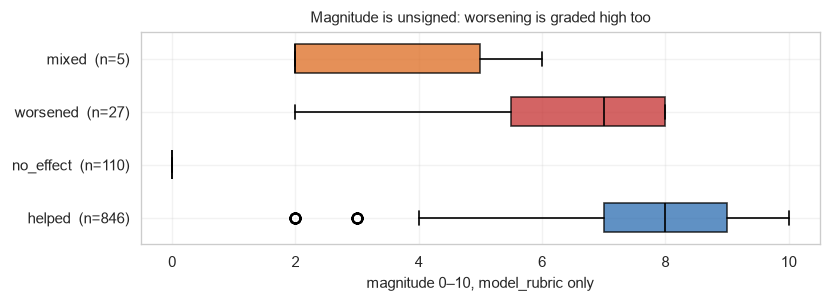

In [8]:
mr = mag[mag.magnitude_basis == "model_rubric"]
tab = mr.pivot_table(index="drug", columns="direction", values="magnitude",
                     aggfunc=["median", "size"]).reindex(list(P.DRUGS))
display(tab)

fig, ax = plt.subplots(figsize=(7, 2.6))
order = [d for d in P.DIRECTIONS if d in set(mr.direction)]
data = [mr.loc[mr.direction == d, "magnitude"].values for d in order]
bp = ax.boxplot(data, orientation="horizontal", widths=0.55, patch_artist=True,
                tick_labels=[f"{d}  (n={len(v)})" for d, v in zip(order, data)])
for patch, d in zip(bp["boxes"], order):
    patch.set_facecolor(P.COLORS.get(d, P.COLORS["muted"]))
    patch.set_alpha(0.75)
for m in bp["medians"]:
    m.set_color("black")
ax.set_xlabel("magnitude 0–10, model_rubric only")
ax.set_title("Magnitude is unsigned: worsening is graded high too", fontsize=9)
plt.tight_layout(); plt.show()

---
# 3. Stated duration

Duration was extracted **only when the author stated it**; it is never inferred from
timestamps or post dates. That makes it rare — 263 of 2,890 effect records, about 9% — and
the resulting distribution is a description of *which durations people bother to write down*,
not of how long effects last.

`acute_session` is the qualitative "during the trip" with no elapsed time attached, so it is
not on the same axis as the others and is shown separately at the left of the ordering.

duration_bin,acute_session,under_24_hours,one_to_six_days,one_to_four_weeks,one_to_six_months,over_six_months,ongoing_at_report,total
drug,,,,,,,,
psilocybin,15,26,16,41,14,9,25,146
ketamine,4,19,16,24,15,6,15,99
lsd,7,4,4,1,2,0,0,18


effect records with a stated duration: 263 of 2,890 (9.1%), from 160 reporter accounts


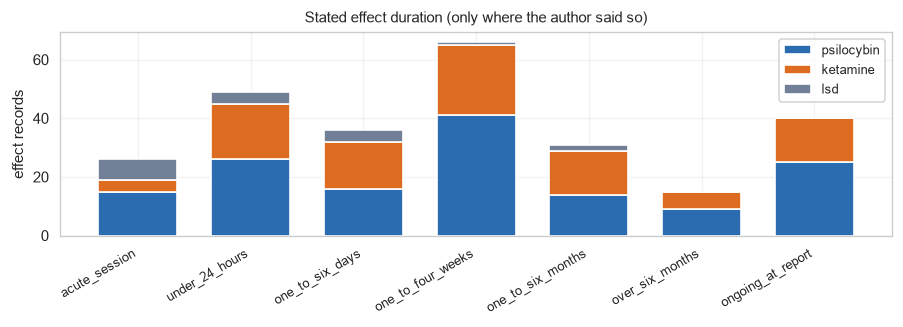

In [9]:
dur = e[e.duration_bin.notna()]
tab = (dur.groupby(["drug", "duration_bin"]).size().unstack(fill_value=0)
       .reindex(index=list(P.DRUGS), columns=list(P.DURATION_BINS), fill_value=0))
display(tab.assign(total=tab.sum(axis=1)))
print(f"effect records with a stated duration: {len(dur):,} of {len(e):,} "
      f"({len(dur) / len(e):.1%}), from {dur.patient.nunique()} reporter accounts")

fig, ax = plt.subplots(figsize=(7.6, 2.8))
bottom = np.zeros(len(P.DURATION_BINS))
x = np.arange(len(P.DURATION_BINS))
for d, color in zip(P.DRUGS, ["#2b6cb0", "#dd6b20", "#718096"]):
    v = tab.loc[d, list(P.DURATION_BINS)].values
    ax.bar(x, v, bottom=bottom, color=color, width=0.7, label=d)
    bottom += v
ax.set_xticks(x, list(P.DURATION_BINS), rotation=30, ha="right", fontsize=7.5)
ax.set_ylabel("effect records")
ax.set_title("Stated effect duration (only where the author said so)", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Adverse events carry their own duration on the same vocabulary. They sit at the short end:
about two thirds of the 129 stated adverse-event durations are under 24 hours or confined to
the session itself. That is a statement about the durations people wrote down for adverse
events, and nothing more — persistent harms are exactly the kind a person may stop posting
about.

In [10]:
ad = f.adverse[f.adverse.duration_bin.notna()]
short = ad.duration_bin.isin(["acute_session", "under_24_hours"]).sum()
display(ad.duration_bin.value_counts().reindex(list(P.DURATION_BINS)).fillna(0)
        .astype(int).rename("adverse events").to_frame())
print(f"{short} of {len(ad)} stated adverse-event durations are acute or <24h "
      f"({short / len(ad):.0%}); {len(f.adverse) - len(ad)} adverse events state no duration")

,adverse events
duration_bin,
acute_session,34
under_24_hours,49
one_to_six_days,20
one_to_four_weeks,9
one_to_six_months,4
over_six_months,4
ongoing_at_report,9


83 of 129 stated adverse-event durations are acute or <24h (64%); 343 adverse events state no duration


---
# 4. Adverse events

**Every number in this section is a share of extractable reports and carries its
denominator. None of them is an incidence.**

The schema keeps three states apart and this notebook never collapses them:

* `reported` — at least one adverse event is stated;
* `explicit_none` — the author explicitly denied adverse effects, with a quote;
* `not_stated` — **silence**. Not a denial, not an absence, not a zero.

## 4.1 The three states

Silence is overwhelming: 2,539 of 2,921 included claims — about 87% — say nothing either
way. Explicit denials (45) are rarer than reports (337) by about seven to one, which is what
you would expect from a forum where people mention side effects when they have them and
otherwise move on.

Any "adverse event rate" that divided reports by all included claims would silently be
treating those 2,539 silent claims as denials. That number is not computed here.

adverse_event_status,reported,explicit_none,not_stated,included_claims
drug,,,,
psilocybin,127,25,1020,1172
ketamine,181,19,1388,1588
lsd,29,1,131,161


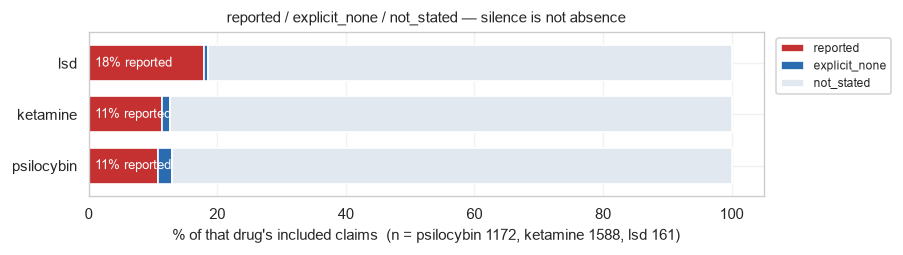

In [11]:
den = P.adverse_denominators(f)
display(den)

pct = 100 * den[list(P.AE_STATUSES)].div(den["included_claims"], axis=0)
ax = pct.plot(kind="barh", stacked=True, figsize=(7.6, 2.2), width=0.7,
              color=["#c53030", "#2b6cb0", "#e2e8f0"])
for i, d in enumerate(pct.index):
    ax.annotate(f"{pct.loc[d, 'reported']:.0f}% reported", (1, i), va="center",
                fontsize=8, color="white")
ax.set_xlabel("% of that drug's included claims  (n = "
              + ", ".join(f"{d} {int(den.loc[d, 'included_claims'])}" for d in P.DRUGS) + ")")
ax.set_ylabel("")
ax.set_title("reported / explicit_none / not_stated — silence is not absence", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 4.2 Reporter-level: who mentioned an adverse event at all

The denominator here is **pairs with an included claim**, i.e. people whose own actual use
of that drug the extractor could confirm. The numerator is pairs whose text yielded at least
one adverse event of any category.

Ketamine (25%) sits higher than psilocybin (19%); LSD is nominally highest at 28% but on 75
pairs, and its interval spans both of the others. The route and setting caveat of §1.1 applies
with more force here: this is a difference in reporting context before it is anything else.

,drug,k,n,rate,ci_lo,ci_hi
0,psilocybin,80,415,0.193,0.158,0.233
1,ketamine,114,463,0.246,0.209,0.287
2,lsd,21,75,0.280,0.191,0.390


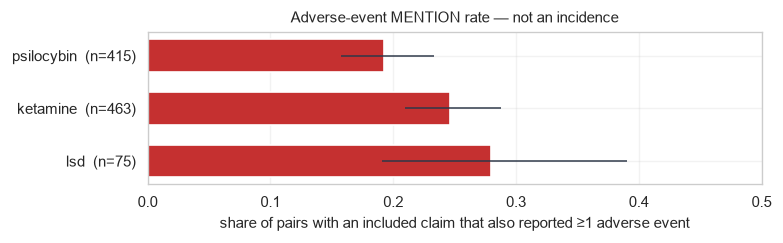

In [12]:
pairs_inc = inc.groupby(["patient", "drug"]).size().rename("claims").reset_index()
ae_pairs = set(map(tuple, f.adverse[["patient", "drug"]].drop_duplicates().values))
pairs_inc["reported_ae"] = [(p, d) in ae_pairs
                            for p, d in zip(pairs_inc.patient, pairs_inc.drug)]
rt = P.rate_table(pairs_inc, "reported_ae")
display(rt.round(3))

fig, ax = plt.subplots(figsize=(6.6, 2.1))
P.ci_bars(ax, rt.drug.tolist(), rt.rate.tolist(), rt.ci_lo.tolist(), rt.ci_hi.tolist(),
          rt.n.tolist(), color=P.COLORS["worsened"])
ax.set_xlim(0, 0.5)
ax.set_xlabel("share of pairs with an included claim that also reported ≥1 adverse event")
ax.set_title("Adverse-event MENTION rate — not an incidence", fontsize=9)
plt.tight_layout(); plt.show()

## 4.3 Categories

472 adverse-event records across 206 reporter accounts. The largest single category is `other`, at
almost half — the closed vocabulary does not fit this population well, and that is a finding
about the schema rather than about the drugs.

Among the named categories, `fatigue_pem_flare` dominates. In a post-viral cohort that
category is genuinely ambiguous: a crash after a session can be a drug effect, an
exertion-triggered flare, or the illness doing what it does. Nothing here can separate them.

,events,reporter accounts
category,,
other,227,115
fatigue_pem_flare,110,70
anxiety_panic,39,32
nausea_gi,33,23
dissociation,17,16
cardiac,15,12
headache,15,14
insomnia,10,9
derealization,6,6


472 adverse-event records from 206 reporter accounts


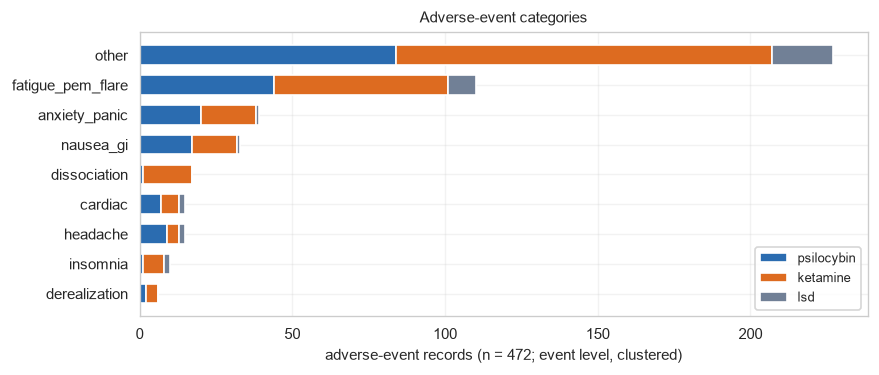

In [13]:
tot = (f.adverse.groupby("category")
       .agg(events=("claim_id", "size"), **{"reporter accounts": ("patient", "nunique")})
       .sort_values("events", ascending=False))
display(tot)
print(f"{len(f.adverse):,} adverse-event records from {f.adverse.patient.nunique()} reporter accounts")

by_drug = (f.adverse.groupby(["category", "drug"]).size().unstack(fill_value=0)
           .reindex(index=tot.index, columns=list(P.DRUGS), fill_value=0)).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.4, 3.2))
left = np.zeros(len(by_drug))
y = np.arange(len(by_drug))
for d, color in zip(P.DRUGS, ["#2b6cb0", "#dd6b20", "#718096"]):
    ax.barh(y, by_drug[d].values, left=left, color=color, height=0.66, label=d)
    left += by_drug[d].values
ax.set_yticks(y, by_drug.index)
ax.set_xlabel(f"adverse-event records (n = {len(f.adverse):,}; event level, clustered)")
ax.set_title("Adverse-event categories", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4.4 Severity

Severity is stated for 413 of 472 records. `severe` is defined in the prompt as requiring
medical care, danger, major persistent impairment, or stopping treatment — it is not a mood
word — and it accounts for about a quarter of graded records. Human review found that only
half of sampled `severe` records meet that definition (19 of 38; `docs/psychedelics_v2_validation_report.md`), so read the
`severe` column as *graded severe by the model*.

The 59 records with no severity are shown as their own column rather than imputed.

severity,mild,moderate,severe,not stated,total
category,,,,,
other,45,92,48,42,227
fatigue_pem_flare,25,52,23,10,110
anxiety_panic,9,19,11,0,39
nausea_gi,10,16,4,3,33
dissociation,7,6,3,1,17
cardiac,3,10,1,1,15
headache,7,4,3,1,15
insomnia,5,2,2,1,10
derealization,1,2,3,0,6


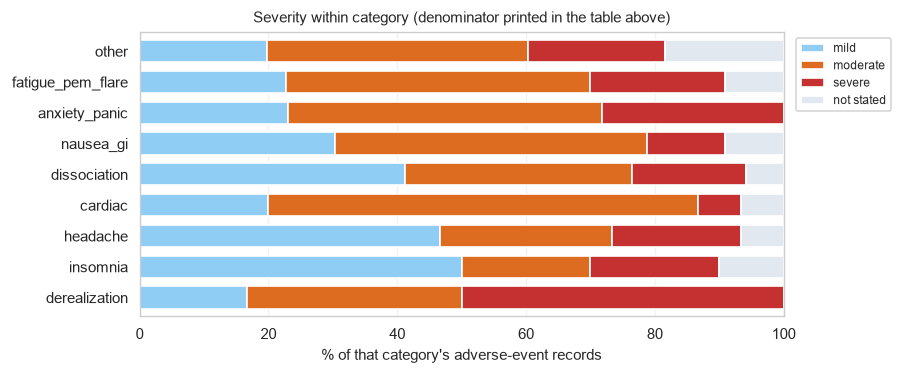

severe: 98 records from 49 reporter accounts, against 472 adverse-event records and 953 pairs with a confirmed included claim


In [14]:
sev = (pd.crosstab(f.adverse.category, f.adverse.severity.fillna("not stated"))
       .reindex(index=tot.index)
       .reindex(columns=[*P.SEVERITIES, "not stated"], fill_value=0))
display(sev.assign(total=sev.sum(axis=1)))

pct = 100 * sev.div(sev.sum(axis=1), axis=0)
ax = pct.iloc[::-1].plot(kind="barh", stacked=True, figsize=(7.6, 3.2), width=0.72,
                         color=["#90cdf4", "#dd6b20", "#c53030", "#e2e8f0"])
ax.set_xlabel("% of that category's adverse-event records")
ax.set_ylabel("")
ax.set_title("Severity within category (denominator printed in the table above)",
             fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

n_sev = int((f.adverse.severity == "severe").sum())
print(f"severe: {n_sev} records from {f.adverse[f.adverse.severity == 'severe'].patient.nunique()} "
      f"reporter accounts, against {len(f.adverse):,} adverse-event records and "
      f"{len(pairs_inc):,} pairs with a confirmed included claim")

---
# 5. Doses

1,338 dose records were extracted. Most of them are not numeric doses.

The extractor was told never to invent a unit or convert an amount, so a passage saying "I
microdose" produces a dose record with an intent and nothing else. That is the right
behaviour and it is why the coverage table comes first: **only 264 of 1,338 dose records
carry an amount at all, and only 273 carry a unit.** Everything downstream is conditioned on
that.

## 5.1 Coverage — what is actually populated

In [15]:
cov = P.dose_coverage(f)
display(cov.rename(columns={"patients": "reporter accounts"}))
display((100 * cov.drop(columns=["dose_records", "patients"])
         .div(cov.dose_records, axis=0)).round(1).rename(
             columns=lambda s: s.replace("with_", "% ")))

,dose_records,reporter accounts,with_amount,with_unit,with_amount_and_unit,with_route,with_intent,with_schedule,with_formulation,with_context
drug,,,,,,,,,,
psilocybin,707,291,195,200,195,109,394,157,141,59
ketamine,557,234,50,54,50,361,85,170,104,258
lsd,74,41,19,19,19,0,43,14,5,5


,% amount,% unit,% amount_and_unit,% route,% intent,% schedule,% formulation,% context
drug,,,,,,,,
psilocybin,27.6,28.3,27.6,15.4,55.7,22.2,19.9,8.3
ketamine,9.0,9.7,9.0,64.8,15.3,30.5,18.7,46.3
lsd,25.7,25.7,25.7,0.0,58.1,18.9,6.8,6.8


## 5.2 Units and routes, canonicalized

`unit` and `route` are free text: `g` / `grams` / `gram`, `IV` / `intravenous` /
`IV infusion` / `infusion`, `nasal` / `intranasal`. They are folded into closed vocabularies
by `P.canon_unit` / `P.canon_route`; anything unmatched lands in `other`, which stayed tiny.

The route split is the clearest structural fact in this dataset. Where a route was stated at
all, ketamine is overwhelmingly IV or otherwise IV/IM stated route (251 of 361) and
psilocybin is entirely oral (109 of 109); **not one LSD dose record states a route**. The
two large arms are not the same kind of exposure, and that difference sits underneath every
comparison in §1 and §4. Note the asymmetry in coverage too: 65% of ketamine dose records
state a route against 15% of psilocybin's, so this is also a picture of what each community
thinks is worth writing down.

drug,ketamine,lsd,psilocybin,total
unit_canon,,,,
count,2,8,1,11
g,0,0,160,160
mcg,0,11,0,11
mg,44,0,35,79
mg/kg,5,0,0,5
mg/ml,2,0,0,2
other,1,0,0,1
oz,0,0,4,4
total,54,19,200,273


drug,ketamine,psilocybin,total
route_canon,,,
intramuscular,10,0,10
intranasal,47,0,47
iv,251,0,251
oral,26,109,135
other,5,0,5
sublingual_buccal,22,0,22
total,361,109,470


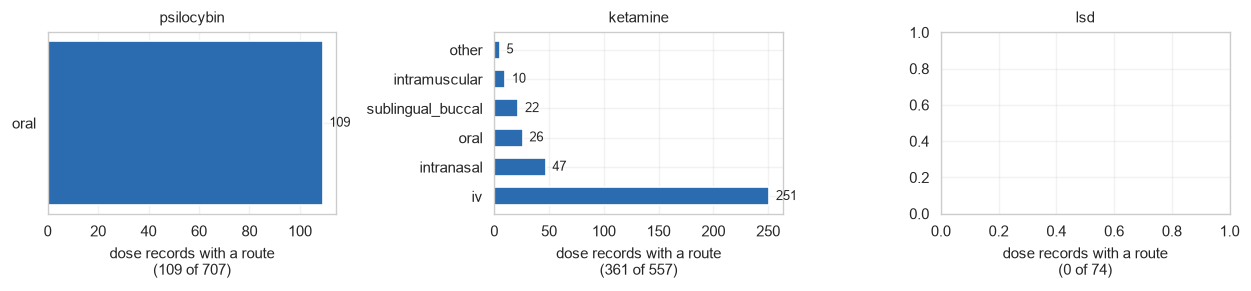

In [16]:
d = f.doses
display(pd.crosstab(d.unit_canon, d.drug, margins=True, margins_name="total"))
display(pd.crosstab(d.route_canon, d.drug, margins=True, margins_name="total"))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.5))
for ax, drug in zip(axes, P.DRUGS):
    sub = d[(d.drug == drug) & d.route_canon.notna()]
    v = sub.route_canon.value_counts().sort_values()
    if len(v):
        P.counts_bars(ax, v.index.tolist(), v.values.tolist(), color=P.COLORS["accent"])
    ax.set_xlabel(f"dose records with a route\n({len(sub)} of {int((d.drug == drug).sum())})")
    ax.set_title(drug, fontsize=9)
plt.tight_layout(); plt.show()

## 5.3 Stated intent

`author_stated_intent` is the author's own word for what kind of dose it was, not a
computed category. Microdosing is the dominant vocabulary for psilocybin and LSD and has
essentially no ketamine equivalent — the same asymmetry v1 found in the community's drug
names, reproduced here from independent text.

In [17]:
display(pd.crosstab(d.intent_canon, d.drug, margins=True, margins_name="total"))
print(f"dose records with no stated intent: {int(d.intent_canon.isna().sum()):,} "
      f"of {len(d):,}")

drug,ketamine,lsd,psilocybin,total
intent_canon,,,,
high_dose_or_trip,8,1,31,40
low_dose,26,0,13,39
microdose,49,41,337,427
other,2,1,13,16
total,85,43,394,522


dose records with no stated intent: 816 of 1,338


## 5.4 The numeric doses that do exist

Only where an amount **and** a canonical unit were both stated. These are distributions of
*what people wrote down*, not of what people took: a memorable heroic dose is far more
likely to be written down than a routine one, so the tails are not tails of use.

Two clusters are worth naming, both on tiny denominators. Psilocybin in grams (155 records,
94 reporter accounts) is bimodal: a microdose cluster at or below half a gram, and a session cluster
in the low single digits. Ketamine in mg (42 records, 25 reporter accounts) spans more than an order
of magnitude, which is unsurprising given that IV infusion, sublingual troche and nasal
spray dosing are not on the same scale and are pooled here. A further 35 psilocybin records
state milligrams, which for a mushroom preparation is more likely a capsule label than a
psilocybin content — another reason not to read these as pharmacological doses.

In [18]:
num = d[d.amount_lower.notna() & d.unit_canon.notna()]
print(f"dose records with amount + canonical unit: {len(num):,} of {len(d):,} "
      f"({len(num) / len(d):.1%}), from {num.patient.nunique()} reporter accounts")
display(num.groupby(["drug", "unit_canon"])
        .agg(records=("amount_lower", "size"), **{"reporter accounts": ("patient", "nunique")},
             q25=("amount_lower", lambda s: s.quantile(.25)),
             median=("amount_lower", "median"),
             q75=("amount_lower", lambda s: s.quantile(.75)),
             max=("amount_lower", "max")).round(2))

dose records with amount + canonical unit: 264 of 1,338 (19.7%), from 142 reporter accounts


records  reporter accounts     q25  median    q75  \
drug       unit_canon                                                      
ketamine   count             2                  2    7.00     8.0    9.0   
           mg               42                 25   21.25    50.0  115.0   
           mg/kg             5                  3    0.50     0.5    1.5   
           other             1                  1  200.00   200.0  200.0   
lsd        count             8                  3    0.50     1.0    1.0   
           mcg              11                  9   10.00    17.0  100.0   
psilocybin count             1                  1    2.00     2.0    2.0   
           g               155                 94    0.40     1.0    3.0   
           mg               35                 22   25.00   100.0  150.0   
           oz                4                  1    1.00     1.0    1.0   

                         max  
drug       unit_canon         
ketamine   count        10.0  
           mg          800.0  
           mg/kg         1.5  
           other       200.0  
lsd        count         2.0  
           mcg         300.0  
psilocybin count         2.0  
           g            15.0  
           mg          500.0  
           oz            1.0

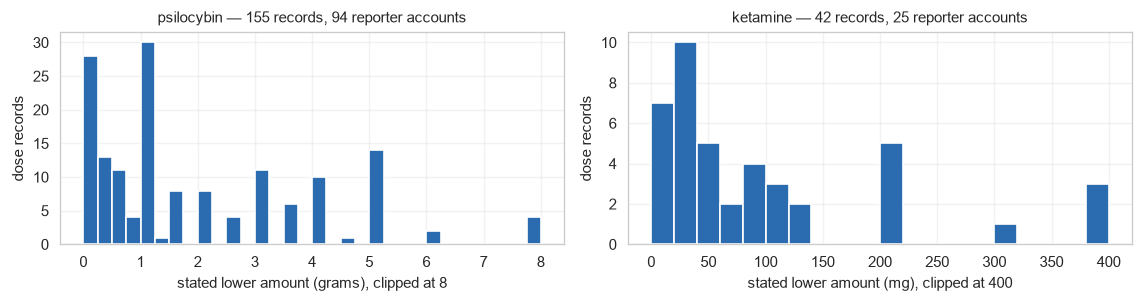

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 2.6))
specs = [("psilocybin", "g", np.arange(0, 8.25, 0.25), "grams"),
         ("ketamine", "mg", np.arange(0, 420, 20), "mg")]
for ax, (drug, unit, bins, xlabel) in zip(axes, specs):
    v = num.loc[(num.drug == drug) & (num.unit_canon == unit), "amount_lower"]
    ax.hist(v.clip(upper=bins[-1]), bins=bins, color=P.COLORS["accent"])
    ax.set_xlabel(f"stated lower amount ({xlabel}), clipped at {bins[-1]:g}")
    ax.set_ylabel("dose records")
    ax.set_title(f"{drug} — {len(v)} records, "
                 f"{num.loc[(num.drug == drug) & (num.unit_canon == unit), 'patient'].nunique()} reporter accounts",
                 fontsize=9)
plt.tight_layout(); plt.show()

---
# 6. Limitations

The limitations of the machinery — the bypassed validation gate, the unreconciled cohort, and
the record-level instability of the extractor — are in notebook 1, §10. Those of the findings
— selection, silence and missingness, confounding, unmeasured setting, and the absence of a
comparator arm — are in notebook 3, §11. Both apply to every number above.

In [20]:
display(HTML(
    '<div style="font-size: 1.2em; font-weight: bold; font-style: italic; margin-top: 1em;">'
    'These findings reflect reporting patterns in online communities, not population-level '
    'treatment effects. This is not medical advice.'
    '</div>'
))
